In [1]:
# ============================================================
# JUPYTER NOTEBOOK: MPG.csv with K-Means Clustering + NLP
# ============================================================

# -------------------------
# 1. Import libraries
# -------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# -------------------------
# 2. Load dataset
# -------------------------
# Make sure MPG.csv is in the same folder as your notebook
df = pd.read_csv("MPG.csv")

print("Shape:", df.shape)
display(df.head())
print("\nColumns:\n", df.columns.tolist())

Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



Columns:
 ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


In [2]:
# -------------------------
# 3. Clean column names
# -------------------------
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]
print(df.columns.tolist())

['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


In [3]:
# -------------------------
# 4. Inspect missing values
# -------------------------
print(df.isnull().sum())
display(df.info())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 35.9 KB


None

In [4]:
# -------------------------
# 5. Basic cleaning
# -------------------------
# Common MPG datasets sometimes use '?' in horsepower
if "horsepower" in df.columns:
    df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# If the dataset has a car name column, use it for NLP
# Typical names: 'car_name', 'name'
text_col = None
for col in ["car_name", "name", "car", "model"]:
    if col in df.columns:
        text_col = col
        break

print("Text column used for NLP:", text_col)

# Show cleaned preview
display(df.head())

Text column used for NLP: name


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [5]:
# -------------------------
# 6. Select numeric columns for K-Means
# -------------------------
# Keep only useful numeric columns if they exist
candidate_numeric = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

numeric_features = [col for col in candidate_numeric if col in df.columns]
print("Numeric features:", numeric_features)

X_num = df[numeric_features].copy()
display(X_num.head())

Numeric features: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa


In [10]:
X = df.copy()

In [15]:
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [19]:
print(dir())

['ColumnTransformer', 'In', 'KMeans', 'OneHotEncoder', 'Out', 'PCA', 'Pipeline', 'SimpleImputer', 'StandardScaler', 'TfidfVectorizer', 'X', 'X_num', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'best_k_num', 'best_score', 'candidate_numeric', 'col', 'df', 'exit', 'get_ipython', 'inertias', 'k', 'k_values', 'km', 'kmeans', 'np', 'numeric_features', 'numeric_pipeline', 'open', 'pd', 'plt', 'quit', 'sil_scores', 'silhouette_score', 'text_col', 'train_test_split']


In [22]:
print(X_num.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
dtype: object


In [25]:
print(locals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', '# ============================================================\n# JUPYTER NOTEBOOK: MPG.csv with K-Means Clustering + NLP\n# ============================================================\n\n# -------------------------\n# 1. Import libraries\n# -------------------------\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nfrom sklearn.cluster import KMeans\nfrom sklearn.preprocessing import StandardScaler, OneHotEncoder\nfrom sklearn.compose import ColumnTransformer\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.impute import SimpleImputer\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.metrics import silhouette_score\nfrom sklearn.decomposition import PCA\n\n# ----

TF-IDF text matrix shape: (398, 299)


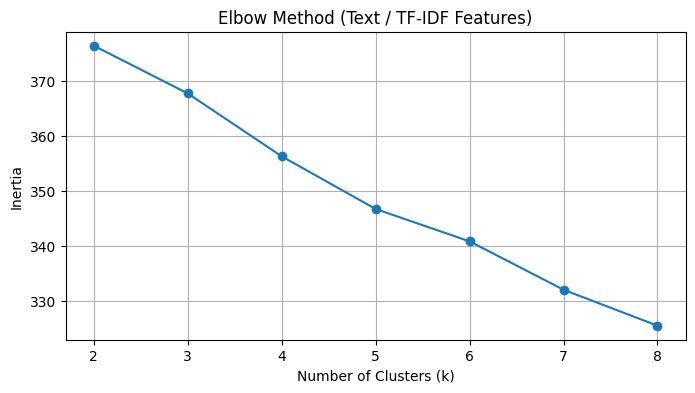

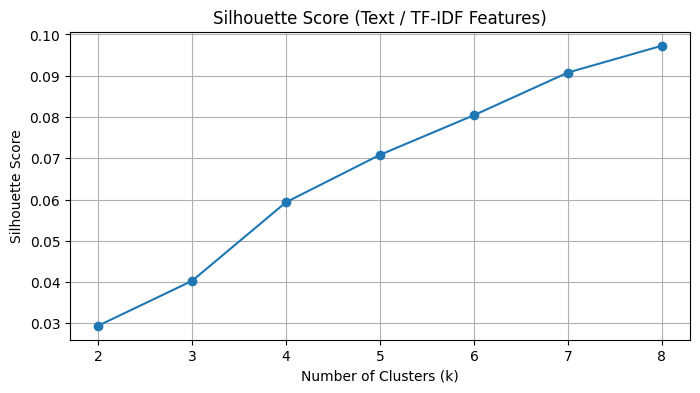

Best k for text clustering: 8


,name,text_cluster
0,chevrolet chevelle malibu,3
1,buick skylark 320,0
2,plymouth satellite,4
3,amc rebel sst,2
4,ford torino,1


text_cluster
0    176
1     51
2     28
3     43
4     31
5     28
6     16
7     25
Name: count, dtype: int64


In [26]:
# -------------------------
# 12. NLP on car names using TF-IDF
# -------------------------
if text_col is not None:
    df[text_col] = df[text_col].fillna("").astype(str).str.lower()

    tfidf = TfidfVectorizer(stop_words="english")
    X_text = tfidf.fit_transform(df[text_col])

    print("TF-IDF text matrix shape:", X_text.shape)

    # Choose k for text clustering
    k_values_text = range(2, 9)
    inertias_text = []
    sil_scores_text = []

    # Silhouette on sparse high-dimensional data can be slow,
    # but works on moderate datasets
    for k in k_values_text:
        kmeans_text = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels_text = kmeans_text.fit_predict(X_text)
        inertias_text.append(kmeans_text.inertia_)

        # silhouette_score can handle sparse matrices
        sil_scores_text.append(silhouette_score(X_text, labels_text))

    plt.figure(figsize=(8, 4))
    plt.plot(list(k_values_text), inertias_text, marker='o')
    plt.title("Elbow Method (Text / TF-IDF Features)")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(list(k_values_text), sil_scores_text, marker='o')
    plt.title("Silhouette Score (Text / TF-IDF Features)")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    best_k_text = list(k_values_text)[np.argmax(sil_scores_text)]
    print("Best k for text clustering:", best_k_text)

    kmeans_text = KMeans(n_clusters=best_k_text, random_state=42, n_init=10)
    df["text_cluster"] = kmeans_text.fit_predict(X_text)

    display(df[[text_col, "text_cluster"]].head())
    print(df["text_cluster"].value_counts().sort_index())
else:
    print("No text column found, so NLP section is skipped.")

In [27]:
# -------------------------
# 13. Show top words per text cluster
# -------------------------
if text_col is not None:
    terms = np.array(tfidf.get_feature_names_out())
    centers = kmeans_text.cluster_centers_

    for i in range(best_k_text):
        top_term_idx = centers[i].argsort()[-10:][::-1]
        top_terms = terms[top_term_idx]
        print(f"Cluster {i} top words: {', '.join(top_terms)}")

Cluster 0 top words: datsun, buick, pontiac, volkswagen, honda, mercury, mazda, rabbit, civic, fiat
Cluster 1 top words: ford, pinto, torino, maverick, fairmont, mustang, gran, granada, 500, sw
Cluster 2 top words: amc, matador, hornet, concord, gremlin, ambassador, dl, pacer, sw, sst
Cluster 3 top words: chevrolet, malibu, vega, classic, impala, chevette, nova, chevelle, citation, carlo
Cluster 4 top words: plymouth, fury, horizon, satellite, custom, duster, valiant, volare, iii, reliant
Cluster 5 top words: dodge, colt, aspen, coronet, custom, se, sw, monaco, aries, brougham
Cluster 6 top words: oldsmobile, diesel, cutlass, omega, brougham, vw, salon, rabbit, volvo, supreme
Cluster 7 top words: toyota, corolla, corona, liftback, mark, ii, tercel, 1200, celica, gt


In [33]:
print(numeric_features)
print(df[numeric_features].dtypes)

['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin']
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
dtype: object


In [35]:
df = df.dropna()
